# **Market Rate Prediction**

**Import Libraries**

In [3]:
import pandas as pd
import numpy as np

**Load Dataset and Reading Data**

In [4]:
import pandas as pd
df=pd.read_csv("supermarket.csv")
df.head(10) #show first 10 rows


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,202-61-1860,C,Naypyitaw,Member,Male,Food and beverages,63.72,5.0,15.9300,334.5300,03/28/2019,17:45,Ewallet,318.60,4.761905,15.9300,7.9
1,408-11-7949,B,Mandalay,Normal,Male,Food and beverages,65.57,6.0,19.6710,413.0910,03/30/2019,10:36,Cash,393.42,4.761905,19.6710,4.8
2,575-69-1189,B,Mandalay,Member,Male,Home and lifestyle,44.42,10.0,22.2100,466.4100,01/03/2019,14:16,Ewallet,444.20,4.761905,22.2100,4.4
3,487-98-9433,B,Mandalay,Member,Male,Food and beverages,30.78,3.0,4.6170,96.9570,03/01/2019,16:53,Cash,92.34,4.761905,4.6170,4.2
4,305-90-2585,B,Mandalay,Normal,Male,Fashion accessories,59.20,2.0,5.9200,124.3200,03/04/2019,11:35,Cash,118.40,4.761905,5.9200,6.4
5,369-57-8629,C,Naypyitaw,Normal,Female,Fashion accessories,39.28,4.0,7.8560,164.9760,03/23/2019,14:33,Ewallet,157.12,4.761905,7.8560,5.7
6,479-50-6276,C,Naypyitaw,Member,Female,Health and beauty,98.82,8.0,39.5280,830.0880,01/08/2019,17:20,Ewallet,790.56,4.761905,39.5280,8.3
7,518-42-6892,B,Mandalay,Member,Male,Health and beauty,92.35,9.0,41.5575,872.7075,01/12/2019,11:42,Ewallet,831.15,4.761905,41.5575,5.9
8,827-46-3731,B,Mandalay,Member,Female,Health and beauty,44.46,10.0,22.2300,466.8300,01/03/2019,10:14,Cash,444.60,4.761905,22.2300,8.6
9,970-36-5488,C,Naypyitaw,Member,Male,Electronic accessories,49.54,2.0,4.9540,104.0340,02/21/2019,13:39,Ewallet,99.08,4.761905,4.9540,7.6


**Data Information**

In [5]:
df.info() # for showing column and their data type




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               200 non-null    object 
 1   Branch                   200 non-null    object 
 2   City                     200 non-null    object 
 3   Customer type            200 non-null    object 
 4   Gender                   200 non-null    object 
 5   Product line             200 non-null    object 
 6   Unit price               200 non-null    float64
 7   Quantity                 188 non-null    float64
 8   Tax 5%                   188 non-null    float64
 9   Total                    188 non-null    float64
 10  Date                     200 non-null    object 
 11  Time                     200 non-null    object 
 12  Payment                  193 non-null    object 
 13  cogs                     188 non-null    float64
 14  gross margin percentage  2

**Missing Data**

In [6]:
df.isnull().sum()


,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,12
Tax 5%,12
Total,12


**Handling of missing data**

In [7]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Payment'] = df['Payment'].fillna(df['Payment'].mode()[0])
df.isnull().sum()


,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,12
Total,12


**Data Transformation (date & time)**

In [8]:
# Fix column names and extract Date & Time features
df.columns = df.columns.str.strip()   # remove extra spaces if any
df_transformed = df.copy()

# Convert Date column to datetime and extract features
df_transformed['Date'] = pd.to_datetime(df_transformed['Date'])
df_transformed['Day'] = df_transformed['Date'].dt.day
df_transformed['Month'] = df_transformed['Date'].dt.month

# Convert Time column to datetime and extract hour
df_transformed['Hour'] = pd.to_datetime(df_transformed['Time']).dt.hour

# Drop unused columns
df_transformed = df_transformed.drop(['Date','Time','Invoice ID'], axis=1)

df_transformed.head(10)


/tmp/ipykernel_1155/527097885.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_transformed['Hour'] = pd.to_datetime(df_transformed['Time']).dt.hour


,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Hour
0,C,Naypyitaw,Member,Male,Food and beverages,63.72,5.0,15.9300,334.5300,Ewallet,318.60,4.761905,15.9300,7.9,28,3,17
1,B,Mandalay,Normal,Male,Food and beverages,65.57,6.0,19.6710,413.0910,Cash,393.42,4.761905,19.6710,4.8,30,3,10
2,B,Mandalay,Member,Male,Home and lifestyle,44.42,10.0,22.2100,466.4100,Ewallet,444.20,4.761905,22.2100,4.4,3,1,14
3,B,Mandalay,Member,Male,Food and beverages,30.78,3.0,4.6170,96.9570,Cash,92.34,4.761905,4.6170,4.2,1,3,16
4,B,Mandalay,Normal,Male,Fashion accessories,59.20,2.0,5.9200,124.3200,Cash,118.40,4.761905,5.9200,6.4,4,3,11
5,C,Naypyitaw,Normal,Female,Fashion accessories,39.28,4.0,7.8560,164.9760,Ewallet,157.12,4.761905,7.8560,5.7,23,3,14
6,C,Naypyitaw,Member,Female,Health and beauty,98.82,8.0,39.5280,830.0880,Ewallet,790.56,4.761905,39.5280,8.3,8,1,17
7,B,Mandalay,Member,Male,Health and beauty,92.35,9.0,41.5575,872.7075,Ewallet,831.15,4.761905,41.5575,5.9,12,1,11
8,B,Mandalay,Member,Female,Health and beauty,44.46,10.0,22.2300,466.8300,Cash,444.60,4.761905,22.2300,8.6,3,1,10
9,C,Naypyitaw,Member,Male,Electronic accessories,49.54,2.0,4.9540,104.0340,Ewallet,99.08,4.761905,4.9540,7.6,21,2,13


**Data Normalized**

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Copy transformed dataframe
df_normalized = df_transformed.copy()

# Select numeric columns to scale
num_cols = ['Unit price','Quantity','Tax 5%','Total','cogs','gross income']

# Apply MinMaxScaler (scales values between 0 and 1)
scaler = MinMaxScaler()
df_normalized[num_cols] = scaler.fit_transform(df_normalized[num_cols]) #to find every column max and min value

# Show first 10 rows of normalized data
df_normalized.head(10)


,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Hour
0,C,Naypyitaw,Member,Male,Food and beverages,0.599345,0.444444,0.314811,0.314811,Ewallet,0.314811,4.761905,0.314811,7.9,28,3,17
1,B,Mandalay,Normal,Male,Food and beverages,0.620230,0.555556,0.391293,0.391293,Cash,0.391293,4.761905,0.391293,4.8,30,3,10
2,B,Mandalay,Member,Male,Home and lifestyle,0.381463,1.000000,0.443201,0.443201,Ewallet,0.443201,4.761905,0.443201,4.4,3,1,14
3,B,Mandalay,Member,Male,Food and beverages,0.227478,0.222222,0.083525,0.083525,Cash,0.083525,4.761905,0.083525,4.2,1,3,16
4,B,Mandalay,Normal,Male,Fashion accessories,0.548318,0.111111,0.110164,0.110164,Cash,0.110164,4.761905,0.110164,6.4,4,3,11
5,C,Naypyitaw,Normal,Female,Fashion accessories,0.323436,0.333333,0.149744,0.149744,Ewallet,0.149744,4.761905,0.149744,5.7,23,3,14
6,C,Naypyitaw,Member,Female,Health and beauty,0.995597,0.777778,0.797254,0.797254,Ewallet,0.797254,4.761905,0.797254,8.3,8,1,17
7,B,Mandalay,Member,Male,Health and beauty,0.922556,0.888889,0.838746,0.838746,Ewallet,0.838746,4.761905,0.838746,5.9,12,1,11
8,B,Mandalay,Member,Female,Health and beauty,0.381915,1.000000,0.443610,0.443610,Cash,0.443610,4.761905,0.443610,8.6,3,1,10
9,C,Naypyitaw,Member,Male,Electronic accessories,0.439264,0.111111,0.090415,0.090415,Ewallet,0.090415,4.761905,0.090415,7.6,21,2,13


## **Data Preparation: Encoding and Train-Test Split**

In [34]:
# 1. Pehle data mein se saari missing values (NaN) wali rows ko khatam karein
df_clean = df.dropna()

# 2. Ab clean data par get_dummies lagayein
df_encoded = pd.get_dummies(df_clean, columns=['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment'], drop_first=True)

# 3. Date, Time aur ID columns ko drop karein aur Target set karein
X = df_encoded.drop(columns=['Invoice ID', 'Date', 'Time', 'Total'])
y = df_encoded['Total']

# 4. Data Split karein
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Features shape:", X_train.shape)

Features shape: (144, 20)


**a. Linear Regression & MSE Error**

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Built Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# 2. Computed MSE error
mse_lr = mean_squared_error(y_test, y_pred_lr)
print(f"Linear Regression Mean Squared Error (MSE): {mse_lr:.4f}")

Linear Regression Mean Squared Error (MSE): 0.0000


**`b. Multiple Regression & Correlation Analysis`**

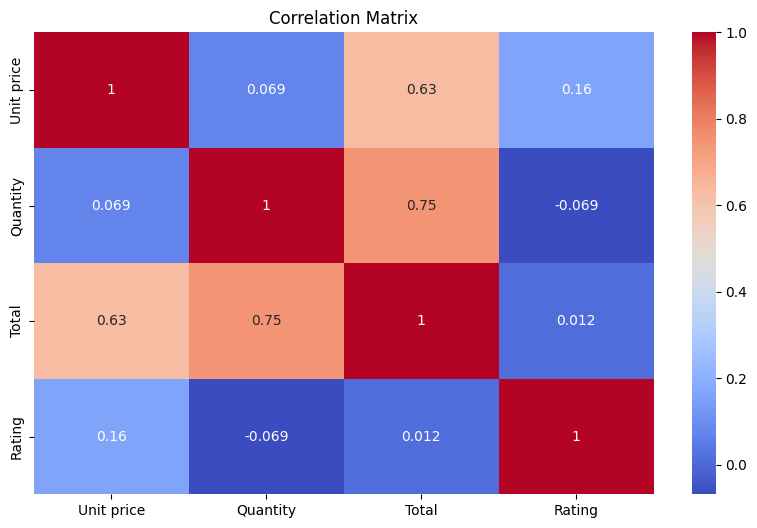

Multiple Regression MSE with Impact Features: 4157.5938


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix display karna
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[['Unit price', 'Quantity', 'Total', 'Rating']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Select impact features based on new logic
impact_features = ['Unit price', 'Quantity']
X_train_multi = X_train[[col for col in X_train.columns if any(imp in col for imp in impact_features)]]
X_test_multi = X_test[[col for col in X_test.columns if any(imp in col for imp in impact_features)]]

multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train)
y_pred_multi = multi_model.predict(X_test_multi)

print(f"Multiple Regression MSE with Impact Features: {mean_squared_error(y_test, y_pred_multi):.4f}")

**c. Polynomial Regression, MAE & R2 Score**

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Implemented Polynomial Regression (Degree = 2)
poly_features = PolynomialFeatures(degree=2)
X_train_poly = poly_features.fit_transform(X_train_multi)
X_test_poly = poly_features.transform(X_test_multi)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

# 2. Calculated MAE metrics & Evaluated R2 scores
mae_poly = mean_absolute_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Polynomial Regression MAE: {mae_poly}")
print(f"Polynomial Regression R2 Score: {r2_poly}")

Polynomial Regression MAE: 1.8394175071989593e-13
Polynomial Regression R2 Score: 1.0


**d. Support Vector Regression (SVR) & Trade-offs**

In [26]:
from sklearn.svm import SVR

# 1. Trained SVR model
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train, y_train)

y_pred_svr = svr_model.predict(X_test)
print(f"SVR Model MSE: {mean_squared_error(y_test, y_pred_svr)}")

SVR Model MSE: 48521.99647270473


**e. Cross-Validation & Model Stability**

In [27]:
from sklearn.model_selection import cross_val_score

# 1. Applied Cross-Validation (K-Fold = 5) on baseline model
cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='r2')

# 2. Validated model stability
print(f"Cross-Validation R2 Scores for 5 Folds: {cv_scores}")
print(f"Mean R2 Score (Stability Measure): {cv_scores.mean()}")

Cross-Validation R2 Scores for 5 Folds: [1. 1. 1. 1. 1.]
Mean R2 Score (Stability Measure): 1.0


**Feature Engineering**

In [28]:
# Revenue per item (Total / Quantity)
df_fe = df_normalized.copy() #for copy the normalized data set
df_fe['Revenue_per_item'] = df_fe['Total'] / (df_fe['Quantity'] + 1e-5)  # avoid divide by zero
df_fe.head(10)


,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Hour,Revenue_per_item
0,C,Naypyitaw,Member,Male,Food and beverages,0.599345,0.444444,0.314811,0.314811,Ewallet,0.314811,4.761905,0.314811,7.9,28,3,17,0.708308
1,B,Mandalay,Normal,Male,Food and beverages,0.620230,0.555556,0.391293,0.391293,Cash,0.391293,4.761905,0.391293,4.8,30,3,10,0.704314
2,B,Mandalay,Member,Male,Home and lifestyle,0.381463,1.000000,0.443201,0.443201,Ewallet,0.443201,4.761905,0.443201,4.4,3,1,14,0.443196
3,B,Mandalay,Member,Male,Food and beverages,0.227478,0.222222,0.083525,0.083525,Cash,0.083525,4.761905,0.083525,4.2,1,3,16,0.375846
4,B,Mandalay,Normal,Male,Fashion accessories,0.548318,0.111111,0.110164,0.110164,Cash,0.110164,4.761905,0.110164,6.4,4,3,11,0.991386
5,C,Naypyitaw,Normal,Female,Fashion accessories,0.323436,0.333333,0.149744,0.149744,Ewallet,0.149744,4.761905,0.149744,5.7,23,3,14,0.449218
6,C,Naypyitaw,Member,Female,Health and beauty,0.995597,0.777778,0.797254,0.797254,Ewallet,0.797254,4.761905,0.797254,8.3,8,1,17,1.025028
7,B,Mandalay,Member,Male,Health and beauty,0.922556,0.888889,0.838746,0.838746,Ewallet,0.838746,4.761905,0.838746,5.9,12,1,11,0.943579
8,B,Mandalay,Member,Female,Health and beauty,0.381915,1.000000,0.443610,0.443610,Cash,0.443610,4.761905,0.443610,8.6,3,1,10,0.443605
9,C,Naypyitaw,Member,Male,Electronic accessories,0.439264,0.111111,0.090415,0.090415,Ewallet,0.090415,4.761905,0.090415,7.6,21,2,13,0.813659


In [11]:
# Group by Customer type and assign avg spend
avg_spend = df_fe.groupby('Customer type')['Total'].transform('mean')
df_fe['Avg_Spend_CustomerType'] = avg_spend
df_fe.head(10)




,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Hour,Revenue_per_item,Avg_Spend_CustomerType
0,C,Naypyitaw,Member,Male,Food and beverages,0.599345,0.444444,0.314811,0.314811,Ewallet,0.314811,4.761905,0.314811,7.9,28,3,17,0.708308,0.273976
1,B,Mandalay,Normal,Male,Food and beverages,0.620230,0.555556,0.391293,0.391293,Cash,0.391293,4.761905,0.391293,4.8,30,3,10,0.704314,0.311594
2,B,Mandalay,Member,Male,Home and lifestyle,0.381463,1.000000,0.443201,0.443201,Ewallet,0.443201,4.761905,0.443201,4.4,3,1,14,0.443196,0.273976
3,B,Mandalay,Member,Male,Food and beverages,0.227478,0.222222,0.083525,0.083525,Cash,0.083525,4.761905,0.083525,4.2,1,3,16,0.375846,0.273976
4,B,Mandalay,Normal,Male,Fashion accessories,0.548318,0.111111,0.110164,0.110164,Cash,0.110164,4.761905,0.110164,6.4,4,3,11,0.991386,0.311594
5,C,Naypyitaw,Normal,Female,Fashion accessories,0.323436,0.333333,0.149744,0.149744,Ewallet,0.149744,4.761905,0.149744,5.7,23,3,14,0.449218,0.311594
6,C,Naypyitaw,Member,Female,Health and beauty,0.995597,0.777778,0.797254,0.797254,Ewallet,0.797254,4.761905,0.797254,8.3,8,1,17,1.025028,0.273976
7,B,Mandalay,Member,Male,Health and beauty,0.922556,0.888889,0.838746,0.838746,Ewallet,0.838746,4.761905,0.838746,5.9,12,1,11,0.943579,0.273976
8,B,Mandalay,Member,Female,Health and beauty,0.381915,1.000000,0.443610,0.443610,Cash,0.443610,4.761905,0.443610,8.6,3,1,10,0.443605,0.273976
9,C,Naypyitaw,Member,Male,Electronic accessories,0.439264,0.111111,0.090415,0.090415,Ewallet,0.090415,4.761905,0.090415,7.6,21,2,13,0.813659,0.273976


**Data Balancing**

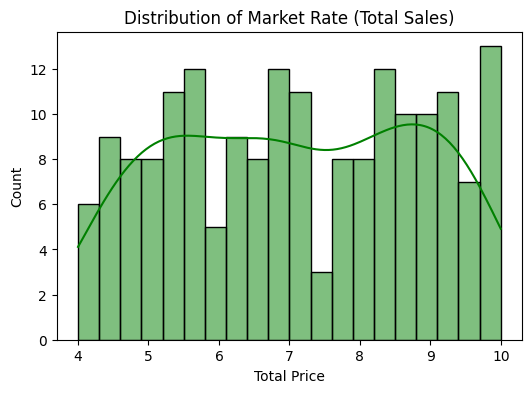

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of target variable Rating
plt.figure(figsize=(6,4)) #set the size of graph
sns.histplot(df_fe['Rating'], kde=True, bins=20, color="green") # set the graph how graph will be draw
plt.title("Distribution of Market Rate (Total Sales)")
plt.xlabel("Total Price")
plt.ylabel("Count")
plt.show()


**Model** **Selection**


In [30]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_fe.drop('Rating', axis=1)
y = df_fe['Rating']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape


((160, 17), (40, 17))

**Decision Tree & Random Forest & Linear Regression (Train Model)**

In [43]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Sahi target (Total) ke sath saare models ka comparison
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train) # Sahi data par train hoga
    y_pred = model.predict(X_test)
    results[name] = {
        "R2 Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

results_df = pd.DataFrame(results).T
print(results_df)

                   R2 Score           MAE          RMSE
Linear Regression  1.000000  9.659540e-14  1.225641e-13
Decision Tree      0.998634  3.867689e+00  5.921012e+00
Random Forest      0.997625  4.235958e+00  7.806400e+00


**Graphical Represenataion**

   Actual Total  Predicted Total
0      436.5165       440.590290
1      286.5240       284.502645
2      145.9920       142.133355
3      437.5875       440.388270
4      282.1140       280.308000
5      123.6900       128.784285
6      103.5405       102.983475
7      333.5220       331.947210
8      415.6320       411.752250
9      487.3680       470.642865


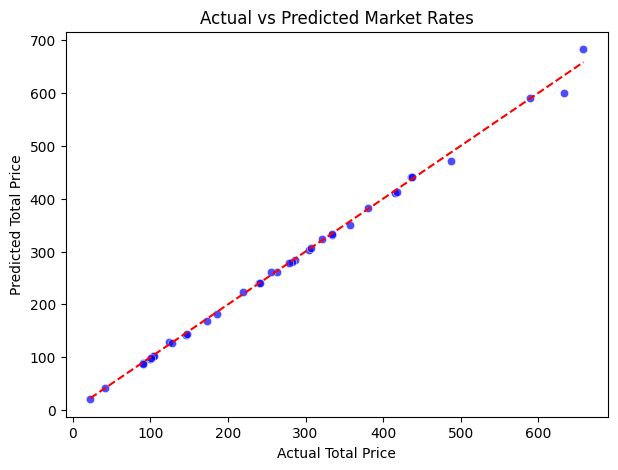

In [44]:
best_model = RandomForestRegressor(random_state=42, n_estimators=100)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Compare Actual vs Predicted
comparison = pd.DataFrame({"Actual Total": y_test.values[:20], "Predicted Total": y_pred[:20]})
print(comparison.head(10))

# Scatter Plot
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Total Price")
plt.ylabel("Predicted Total Price")
plt.title("Actual vs Predicted Market Rates")
plt.show()